# Phase Transitions of a xSM

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

import pandas as pd

import multiprocessing as mp
from joblib import Parallel, delayed

from tqdm.notebook import tqdm

import os

from cosmoTransitions import transitionFinder
from cosmoTransitions import pathDeformation as pthd

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar
from scipy.optimize import shgo

from time import perf_counter

import Higgs.predictions as HP
import Higgs.bounds as HB
import Higgs.signals as HS

pred = HP.Predictions()
bounds = HB.Bounds('/home/diegogt/hbdataset/')
signals = HS.Signals('/home/diegogt/hsdataset')

from xSM_Tadpole import xSMt as xSM

def physical_to_lagrangian(m1, m2, theta, v, lHS, lS, mu3):
    lH   = (m1**2 * np.cos(theta)**2 + m2**2 * np.sin(theta)**2)/(2 * v**2)
    muHS = np.sin(theta) * np.cos(theta) / v * (m1**2 - m2**2)
    muS2 = 0.5 * lHS * v**2 - (m1**2 * np.sin(theta)**2 + m2**2 * np.cos(theta)**2)
    muH2 = lH * v**2
    mu13 = - 0.5 * v**2 * muHS

    return dict(muH2=muH2, lH=lH, mu13=mu13, muHS=muHS, lHS=lHS, mu3=mu3, lS=lS, muS2=muS2)

## Examine the Potential 
(Specific Parameters)

In [13]:
m1  = 125.20
m2  = 60
th  = 0.0
v0  = 246.22
lHS = 0.265609
lS  = 0.107227
mu3 = 0*246.22

params = physical_to_lagrangian(
    m1    = m1,
    m2    = m2,
    theta = th,
    v     = v0,
    lHS   = lHS,
    lS    = lS,
    mu3   = mu3
)

lH   = params["lH"]
lHS  = params["lHS"]
muHS = params["muHS"]
lS   = params["lS"]
mu3  = params["mu3"]
muH2 = params["muH2"]
muS2 = params["muS2"]
mu13 = params["mu13"]

lSmin = (lHS*v0**2-2*m2**2)**2/(2*v0**2*m1**2)

for i in params.keys():
    if i == "lS":
        print(f"{i} -> {params[i]}  lS min = {lSmin}")
    else:
        print(f"{i} -> {params[i]}")

model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3', 'muS2']})
model.Tmax = 250
v = model.v_os
w = model.w_os

muH2 -> 7837.52
lH -> 0.1292801978686813
mu13 -> -0.0
muHS -> 0.0
lHS -> 0.265609
mu3 -> 0.0
lS -> 0.107227  lS min = 0.0416989066479713
muS2 -> 4451.178308817799


### Tree-Level Potential

In [14]:
# --- Symmetric Extrema ---
coeffs = [lS,-mu3,-muS2, mu13]
roots = np.roots(coeffs)
real_roots = roots[np.abs(roots.imag) < 1e-8].real
d2V0 = -muS2 - 2.0 * mu3 * real_roots + 3.0 * lS * real_roots**2
minima_roots = real_roots[d2V0 > 0]

print("="*50)
print("    Symmetric Vaccua")
print("="*50)
print(f"The symmetric extrema are: {np.round(real_roots, 4)}")
print(f"The symmetric minima are: {np.round(minima_roots, 4)}")
print(f"The false vacuum is at s={w:.4f} GeV")
print()

# --- Non Symmetric Extrema ---
sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)

a = (lS - lHS**2/(4*lH))
b = -(mu3 + 3*lHS*muHS/(4*lH))
c = (lHS*muH2 - muHS**2 - 2*lH*muS2)/(2*lH)
d = (muH2*muHS)/(2*lH) + mu13
X = np.roots([a, b, c, d])
realX = X[np.abs(X.imag) < 1e-8].real
validX = realX[(sm < realX) & (realX < sp)]
d2V = (lHS*muH2 - muHS**2 - 2*lH*muS2)/(2*lH) - (mu3 + 3*lHS*muHS/(2*lH)) * validX + (lS - lHS**2/(4*lH)) * validX**2
minimaX = validX[d2V > 0]
root_hp  =  np.sqrt(-validX**2 * lHS + 2*muH2 - 2*validX*muHS) / (np.sqrt(2) * np.sqrt(lH))

print("="*50)
print("    Non-Symmetric Vaccua")
print("="*50)
print(f"The validity range of the Non-symmetric solutions is: [{sm:.4f},{sp:.4f}]")
print(f"The Non-Symmetric, valid, extrema are: {np.round(validX, 4)}, h-> {np.round(root_hp, 4)}")
print(f"The Non-Symmetric, valid, minima are: {np.round(minimaX, 4)}")
print()

print("="*50)
print("    Stability of the Potential")
print("="*50)
Vv = model.Vtot(np.array([[v, 0.0]]), 0.0)
Vw = model.Vtot(np.array([[0.0, w]]), 0.0)
print(f"V(v, 0) = {Vv[0]:.0f}")
print(f"V(0, w) = {Vw[0]:.0f}")

if Vv[0] < Vw[0]:
    print(f"The EW vaccum is stable")

if Vv[0] > Vw[0]:
    print(f"The EW vaccum is meta-stable")

    Symmetric Vaccua
The symmetric extrema are: [ 203.7443 -203.7443    0.    ]
The symmetric minima are: [ 203.7443 -203.7443]
The false vacuum is at s=203.7443 GeV

    Non-Symmetric Vaccua
The validity range of the Non-symmetric solutions is: [-242.9310,242.9310]
The Non-Symmetric, valid, extrema are: [0.], h-> [246.22]
The Non-Symmetric, valid, minima are: [0.]

    Stability of the Potential
V(v, 0) = -118786018
V(0, w) = -46194028
The EW vaccum is stable


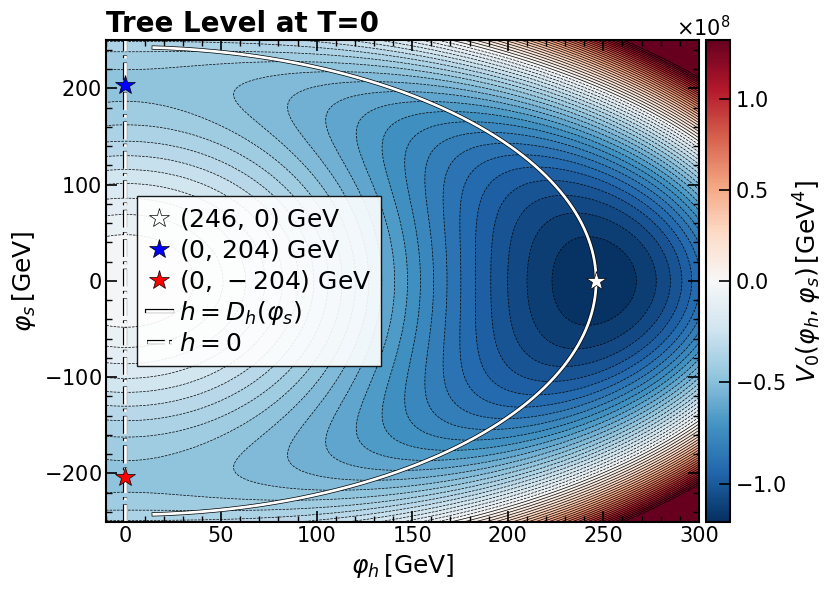

In [15]:
# Set the values of h & s 
hmin, hmax = (-10, 300)
smin, smax = (-250, 250)

# Create the Paths 
s_path  = np.linspace(smin, smax, 1000)
h_zeros = np.zeros_like(s_path)
h_plus  = np.full_like(s_path, np.nan)
h_minus = np.full_like(s_path, np.nan)

radicand = -s_path**2 * lHS + 2*muH2 - 2*s_path*muHS
valid = radicand >= 0
h_plus[valid]  =  np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))
h_minus[valid] = -np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))

# Potential Grid 
h_vals = np.linspace(hmin, hmax, 200)
s_vals = np.linspace(smin, smax, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.V0(X_grid).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.V0(np.array([[0.0, 0.0]]))

# Normalize the cmap
norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max()) # Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

# Create the Figure
fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(root_hp[-1], validX[-1], 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({root_hp[-1]:.0f},\,{validX[-1]:.0f})$ GeV')
ax.plot(0, minima_roots[0], 'b*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({0},\,{minima_roots[0]:.0f})$ GeV')
ax.plot(0, minima_roots[1], 'r*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({0},\,{minima_roots[1]:.0f})$ GeV')
ax.plot(h_plus, s_path, label=r'$h=D_h(\varphi_s)$', color='w', lw=2, ls='-', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])
ax.plot(h_zeros, s_path, label=r'$h=0$', color='w', lw=2, ls='-.', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])

# Make it Pretty
ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "center left", bbox_to_anchor=(0.03, 0.5),ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/TL_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

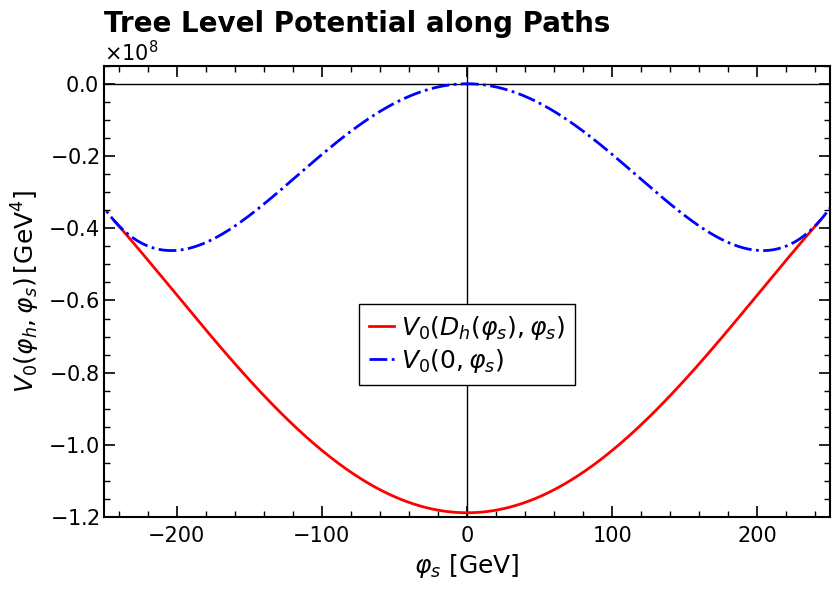

In [16]:
# Potential allong paths
sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)
SPath = np.linspace(sm,sp,500)
SPath0 = np.linspace(smin-500,smax+500,1000)

Vs0 = mu13*SPath0-0.5*muS2*SPath0**2-mu3/3*SPath0**3+lS/4*SPath0**4

Vs = (-(muH2**2)/(4*lH)
      + SPath*((muH2*muHS)/(2*lH) + mu13)
      - SPath**2*(-12*lHS*muH2 + 12*muHS**2 + 24*lH*muS2)/(48*lH)
      - SPath**3*(16*lH*mu3 + 12*lHS*muHS)/(48*lH)        
      - SPath**4*(3*lHS**2 - 12*lH*lS)/(48*lH))

# Create the plot
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(SPath, Vs, label=r'$V_{0}\left(D_h(\varphi_s),\varphi_s\right)$', color='r', lw=2, ls='-')
ax.plot(SPath0, Vs0, label=r'$V_{0}\left(0,\varphi_s\right)$', color='b', lw=2, ls='-.')

ax.set_xlim(-250, 250)
ax.set_ylim(-1.2e8, 0.5e7)

ax.set_xlabel(r'$\varphi_s$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper center", bbox_to_anchor=(0.5, 0.5),
               ncol = 1, edgecolor="black", framealpha=1, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level Potential along Paths", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/TL_Path.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Coleman Weinberg ($T=0$)

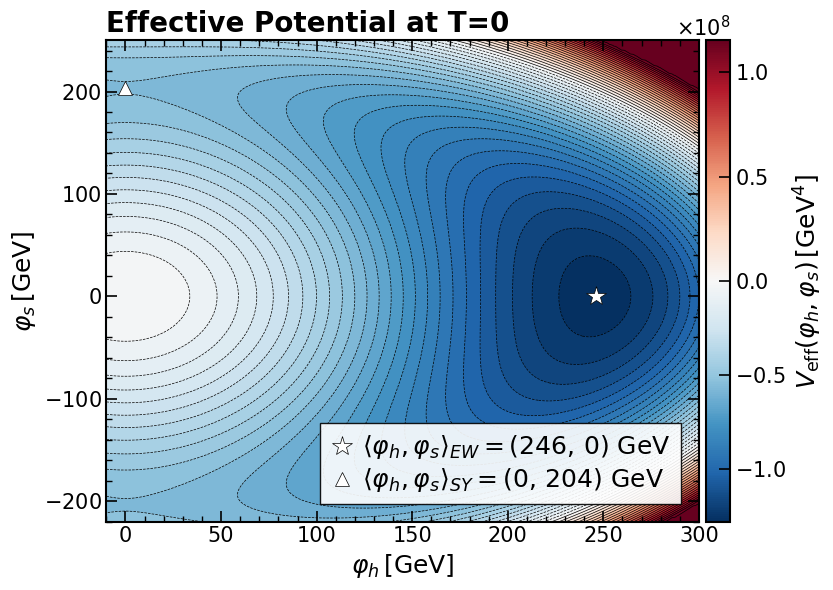

In [17]:
# Grid in (h, s)
h_vals = np.linspace(-10, 300, 200)
s_vals = np.linspace(-220, 250, 250)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, 0.0).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), 0.0)

norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max()) # Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(v, 0, 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle_{{EW}} = ({v:.0f},\,{0:.0f})$ GeV')
ax.plot(0, w, 'w^', markersize=10, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle_{{SY}} = ({0:.0f},\,{w:.0f})$ GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Effective Potential at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/CW_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Phase Transition

In [18]:
trans = model.calcTcTrans()
Tc   = trans[0]['Tcrit']
high = trans[0]['high_vev']
low  = trans[0]['low_vev']
xi_c = abs(low[0] - high[0]) / Tc
print(f"Tc = {Tc:.4f} GeV  |  xi_c = {xi_c:.2f}")

Tracing phase starting at x = [ 2.46220001e+02 -2.08616529e-06] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
......................................................................................................................................................
Tracing phase starting at x = [-1.66025676e-06 -1.92363315e+02] ; t = 125.01021534403922
Tracing minimum down
traceMinimum t0 = 125.01
..............................
Tracing minimum up
traceMinimum t0 = 125.01
.......................................
Tracing phase starting at x = [-1.86179276e-05 -1.96931958e+02] ; t = 97.29497187036804
Tracing minimum down
traceMinimum t0 = 97.295
.....................................
Tracing minimum up
traceMinimum t0 = 97.295
..............................................
Tc = 113.1483 GeV  |  xi_c = 1.76


In [19]:
# Compute the rest

trans = model.findAllTransitions()
print()
print("The Model has",len(model.TnTrans),"transition(s)")

if len(model.TnTrans) != 0:
    Trans = model.TnTrans[0]

    Tc    = Trans['crit_trans']['Tcrit']
    highc = Trans['crit_trans']['high_vev']
    lowc  = Trans['crit_trans']['low_vev']
    xic   = abs(lowc[0] - highc[0]) / Tc
    Tn    = Trans['Tnuc']
    highn = Trans['high_vev']
    lown  = Trans['low_vev']
    xin   = abs(lown[0] - highn[0]) / Tc

    print(f"Tc = {Tc:.4f} GeV  |  xi_c = {xi_c:.2f}")


The Model has 0 transition(s)


In [ ]:
# Grid in (h, s)
h_vals = np.linspace(-5, 200, 200)
s_vals = np.linspace(-180, 5, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, Tc).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 70))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), Tc)

norm = Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=55, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=55, colors='k', linewidths=0.3, alpha=1)

ax.plot(high[0], high[1], 'r*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'High Phase ({-high[0]:.0f}, {high[1]:.0f}) GeV')
ax.plot(low[0], low[1], 'b*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'Low Phase ({low[0]:.0f}, {low[1]:.0f}) GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s,T) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01), 
          ncol = 1, edgecolor="black", framealpha=0.65, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

annotation = (rf"$T_c   = {Tc:.2f} \, \mathrm{{GeV}}$"
              "\n"rf"$T_n = {Tn:.2f}\, \mathrm{{GeV}}$"
              "\n"rf"$\xi_c = {xi_c:.2f}$")
ax.text(0.05, 0.95, annotation,transform=ax.transAxes,fontsize=18,verticalalignment='top',horizontalalignment='left',
       bbox=dict(facecolor='white', edgecolor='black', alpha=0.65))

plt.title(rf"Effective Potential at {Tc:.2f} GeV", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/Tc_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

NameError: name 'Tn' is not defined

## Analytical Scan

### $Z_2$ Symmetric Model

In [15]:
# Fixed Inputs
m1, v   = 125.2, 246.22
th, mu3 = 0.0, 0.0
g  = 0.6528226789050443
gp = 0.34994875330215097
yb = 0.024025892825142788
yt = 0.9902137038141565

# Create the grid
lHS = np.geomspace(1e-3, 1, 100)
lS  = np.geomspace(1e-6,  1,  100)
m2  = np.linspace(10,  60,  100)
LHS, LS, M2 = np.meshgrid(lHS, lS, m2, indexing='ij')

# Lagrangian Parameters
p = physical_to_lagrangian(m1=m1, m2=M2, theta=th, v=v, lHS=LHS, lS=LS, mu3=mu3)
lH, muH2, muS2 = p['lH'], p['muH2'], p['muS2']

# Thermal Coefficients
cH = (9*g**2 + 3*gp**2 + 12*yb**2 + 12*yt**2 + 24*lH + 2*LHS) / 48
cS = LS/4 + LHS/6

# Transition Temperatures
T0h2 = muH2 / cH
T0s2 = muS2 / cS
Tc2 = (-np.sqrt(LS)*muH2 + np.sqrt(lH)*muS2) / (cS*np.sqrt(lH) - cH*np.sqrt(LS))

# VEVs
vTc2 = (muH2 - cH*Tc2) / lH
wTc2 = (muS2 - cS*Tc2) / LS

# Validity Mask
valid = (
    (muS2 > 0) & (LS > 0) & (Tc2 > 0) 
    & (Tc2 < T0h2) & (Tc2 < T0s2) & (T0s2 > T0h2) 
    & (LHS > 2*np.sqrt(lH*LS)) & (LS > (LHS*v**2 - 2*M2**2)**2 / (2*v**2*m1**2))
)

# Save only relevant data
idx = np.where(valid)
results = dict(
    lHS=LHS[idx], lS=LS[idx], m2=M2[idx],
    Tc=np.sqrt(Tc2[idx]),
    vTc=np.sqrt(vTc2[idx]),
    wTc=np.sqrt(wTc2[idx]),
    xic=np.sqrt(vTc2[idx])/np.sqrt(Tc2[idx])
)

results_df = pd.DataFrame(results)

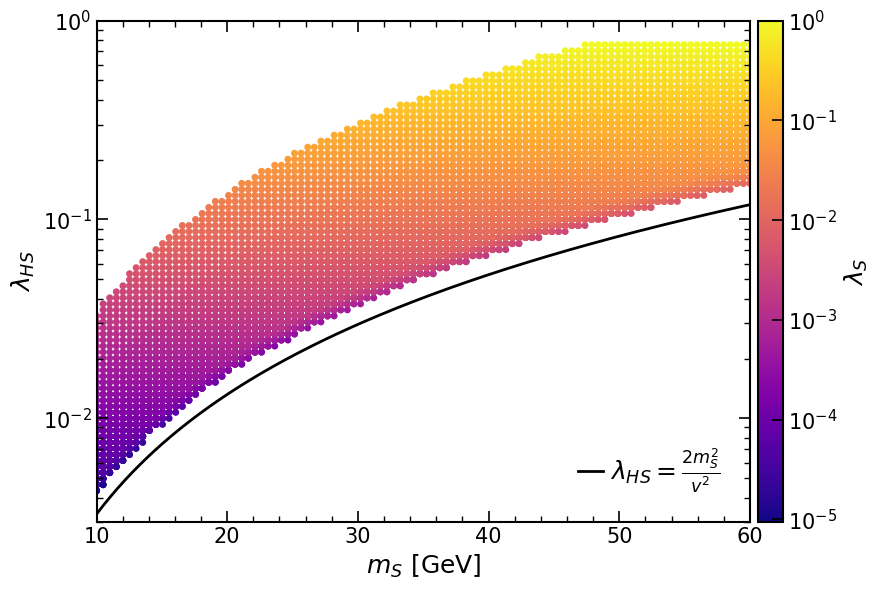

In [20]:
df = results_df[(results_df.xic>1)&(results_df.lS>(results_df.lHS*(results_df.lHS*v**2-2*results_df.m2**2))/(2*m1**2))]

# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/246.22**2

cmap = plt.cm.plasma
norm = LogNorm(vmin=df['lS'].min(), vmax=df['lS'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['m2'], df['lHS'], c=df['lS'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_S^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_S \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(10, 60)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\lambda_S$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# Log-scale colorbar ticks
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"$\mathbb{Z}_2$ limit. $\exists T_n$", loc='left', fontsize=20)
plt.tight_layout()
plt.savefig("Figures/Analytic_m2-lHS.pdf", format="pdf", bbox_inches="tight")
plt.show()


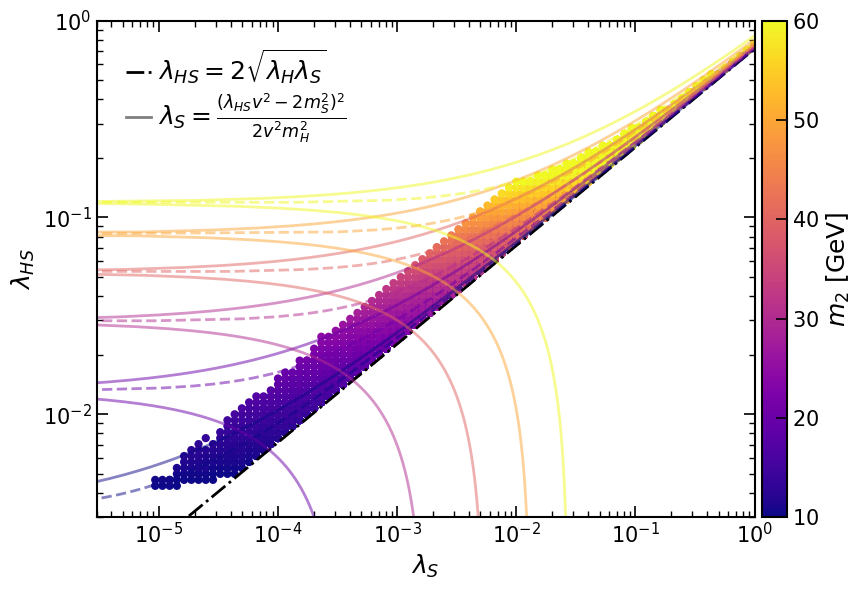

In [ ]:
df = results_df[(results_df.xic>1)&(results_df.lS>(results_df.lHS*(results_df.lHS*v**2-2*results_df.m2**2))/(2*m1**2))]

cmap = plt.cm.plasma
norm = Normalize(vmin=df['m2'].min(), vmax=df['m2'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))


# SM values (adjust if you're using different fixed values)
m1 = 125.20  # GeV
v0 = 246.22   # GeV
lH = 0.5*m1**2/v0**2

def lS_min(lHS, m2):
    return (lHS * v0**2 - 2 * m2**2)**2 / (2 * v0**2 * m1**2)

def lS_JM(lHS, m2):
    return (lHS * (lHS*v0**2 - 2 * m2**2)) / (2 * m1**2)

lHS_vals = np.geomspace(1e-3, 1e0, 300)
LSCrit   = lHS_vals**2/(4*lH)
ax.plot(LSCrit, lHS_vals, c='k', lw=2, ls='-.')

m2_lines = [10, 20, 30, 40, 50, 60]

for m2_i in m2_lines:
    lS_curve = lS_min(lHS_vals, m2_i)
    lSJM_curve = lS_JM(lHS_vals, m2_i)
    ax.plot(lS_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2)
    ax.plot(lSJM_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2, ls='--')

sc = ax.scatter(df['lS'], df['lHS'], c=df['m2'], cmap=cmap, norm=norm,
                 s=35, alpha=1, edgecolors='None')

ax.set_xlabel(r'$\lambda_S$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(3e-6, 1e0)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$m_2\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

handles_list = [mlines.Line2D([], [], color='k', linestyle='-.', linewidth=2, alpha=1, label=r"$\lambda_{HS}=2\sqrt{\lambda_H \lambda_S}$"),
                mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{(\lambda_{HS}v^2 - 2m_S^2)^2}{2v^2m_H^2}$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"$\mathbb{Z}_2$ Limit. $\exists T_n$", loc='left', fontsize=20)
plt.tight_layout()
plt.savefig("Figures/Analytic_lS-lHS.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
results_df[(results_df.xic>1)&(results_df.m2>59.9)&(results_df.lHS>0.265)&(results_df.lHS<0.275)]

,lHS,lS,m2,Tc,vTc,wTc,xic
21296,0.265609,0.046416,60.0,36.012854,237.751576,307.142376,6.601853
21307,0.265609,0.053367,60.0,53.408230,227.178695,283.421258,4.253627
21324,0.265609,0.061359,60.0,65.380138,217.062295,261.515657,3.320004
21349,0.265609,0.070548,60.0,74.697035,207.344592,241.242879,2.775808
21383,0.265609,0.081113,60.0,82.352109,197.971155,222.439644,2.403960
21428,0.265609,0.093260,60.0,88.846037,188.889621,204.958934,2.126033
21487,0.265609,0.107227,60.0,94.476459,180.048433,188.667281,1.905749
21567,0.265609,0.123285,60.0,99.438940,171.395517,173.442365,1.723626


### General Model

#### Test

In [298]:
# Fixed Inputs
m1, v   = 125.2, 246.22
g  = 0.6528226789050443
gp = 0.34994875330215097
yb = 0.024025892825142788
yt = 0.9902137038141565

# Test Parameters
m2  = 60
th  = 0.1
lHS = 0.265609
lS  = 0.107227
mu3 = 0.24622

# Lagrangian Parameter
params = physical_to_lagrangian(
    m1    = m1,
    m2    = m2,
    theta = th,
    v     = v,
    lHS   = lHS,
    lS    = lS,
    mu3   = mu3
)

lH   = params["lH"]
lHS  = params["lHS"]
muHS = params["muHS"]
lS   = params["lS"]
mu3  = params["mu3"]
muH2 = params["muH2"]
muS2 = params["muS2"]
mu13 = params["mu13"]

# Thermal Coeficients
cH = (9*g**2 + 3*gp**2 + 12*yb**2 + 12*yt**2 + 24*lH + 2*lHS) / 48
cS = lS/4 + lHS/6
c1 = (-mu3 + 2*muHS)/12

# Find Symmetric Minima
def find_w(T):
    a = lS
    b = -mu3
    c = cS*T**2 - muS2
    d = c1*T**2 + mu13
    X = np.roots([a,b,c,d])
    RealX = X[np.abs(X.imag) < 1e-8].real
    d2V   = cS*T**2 - muS2 - 2*mu3*RealX + 3*lS*RealX**2
    candidatews = RealX[d2V>0]
    return candidatews

# Find ElectroWeak Minima
def find_EW(T):
    Tew = np.sqrt(muH2/cH) # Safety check on high temerature
    if T>Tew:
        return [0], [0]
    sp = (-muHS+(-2*cH*lHS*T**2+2*lHS*muH2+muHS**2)**0.5)/(lHS)
    sm = (-muHS-(-2*cH*lHS*T**2+2*lHS*muH2+muHS**2)**0.5)/(lHS)

    a = lS - (lHS**2)/(4*lH)
    b = -mu3 - (3*lHS*muHS)/(4*lH)
    c = (cS-(cH*lHS)/(2*lH))*T**2 + (lHS*muH2)/(2*lH) - (muHS**2)/(2*lH) - muS2
    d = mu13 + (muH2*muHS)/(2*lH) + (c1-(cH*muHS)/(2*lH))*T**2
    X = np.roots([a,b,c,d])
    RealX = X[np.abs(X.imag) < 1e-8].real
    validX = RealX[(sm < RealX) & (RealX < sp)]
    d2V = (cS-(cH*lHS)/(2*lH))*T**2 + (lHS*muH2)/(2*lH) - (muHS**2)/(2*lH) - muS2 - (2*mu3 - (3*lHS*muHS)/(2*lH))*validX + (2*lS - (lHS**2)/(2*lH))*validX**2
    candidatesvs = validX[d2V > 0]
    candidatesvh = np.sqrt((2*muH2 - 2*cH*T**2 - 2*muHS*candidatesvs - lHS*candidatesvs**2)/(2*lH))
    return candidatesvh,candidatesvs

# Select the true Symmetric Minima
def global_symmetric_min(T):
    ws = find_w(T)
    if len(ws) == 0:
        return np.nan, np.nan
    Vs = VHT(0.0, ws, T)
    i = np.argmin(Vs)
    return ws[i], Vs[i]

# Select the true EW Minima
def global_EW_min(T):
    vh, vs = find_EW(T)
    vh = np.asarray(vh, dtype=float)
    vs = np.asarray(vs, dtype=float)
    if len(vh) == 0:
        return np.nan, np.nan, np.nan
    Vs = VHT(vh, vs, T)
    i = np.argmin(Vs)
    return vh[i], vs[i], Vs[i]

# High Temperature Potential
def VHT(h,s,T):
    V = (cH*T**2-muH2)*(h**2)/(2) + lH*(h**4)/(4) + (c1*T**2+mu13)*s + (cS*T**2-muS2)*(s**2)/(2) - mu3*(s**3)/(3) + lS*(s**4)/(4) + 0.5*muHS*s*h**2 + 0.25*lHS*s**2*h**2
    return V 

# Delta Function
def delta_V(T):
    _, V_sym = global_symmetric_min(T)
    _, _, V_ew = global_EW_min(T)
    if np.isnan(V_sym) or np.isnan(V_ew):
        return np.nan
    return V_ew - V_sym

def find_Tc(Tmin=1e-3, Tmax=300, nscan=200):
    Ts = np.linspace(Tmin, Tmax, nscan)
    dV = np.array([delta_V(T) for T in Ts])
    valid = np.isfinite(dV)
    Ts, dV = Ts[valid], dV[valid]
    sign_changes = np.where(np.diff(np.sign(dV)) != 0)[0]

    if len(sign_changes) == 0:
        return None

    roots = []
    for idx in sign_changes:
        a, b = Ts[idx], Ts[idx+1]
        try:
            Tc = brentq(delta_V, a, b, xtol=1e-10, rtol=1e-12)
            if Tc < np.sqrt(muH2/cH):
                roots.append(Tc)
            else:
                continue
        except ValueError:
            continue

    return roots

from time import perf_counter

start = perf_counter()

# --- Strength of the transition ---
Tc = find_Tc()[0]
vh_c, vs_c, Vew = global_EW_min(Tc)
strength = vh_c / Tc

end = perf_counter()

print(f"Tc = {Tc:.4f} GeV")
print(f"v(Tc) = {vh_c:.4f} GeV, u(Tc) = {vs_c:.4f} GeV, V(v,u,Tc) = {Vew} GeV^4")
print(f"xic = v(Tc)/Tc = {strength:.4f}")

print(f"Elapsed time = {end-start:.6f} s")

Tc = 68.7619 GeV
v(Tc) = 211.0858 GeV, u(Tc) = 18.1193 GeV, V(v,u,Tc) = -66935033.35084006 GeV^4
xic = v(Tc)/Tc = 3.0698
Elapsed time = 0.039577 s


#### Scan

##### Functions

In [2]:
def create_params(m2, th, lHS, lS, mu3):
    # Fixed Inputs
    m1, v   = 125.2, 246.22
    g  = 0.6528226789050443
    gp = 0.34994875330215097
    yb = 0.024025892825142788
    yt = 0.9902137038141565

    p = physical_to_lagrangian(m1, m2, th, v, lHS, lS, mu3)
    muH2, lH, mu13, muHS, muS2 = p['muH2'], p['lH'], p['mu13'], p['muHS'], p['muS2']

    cH = (9*g**2 + 3*gp**2 + 12*yb**2 + 12*yt**2 + 24*lH + 2*lHS) / 48
    cS = lS/4 + lHS/6
    c1 = (-mu3 + 2*muHS)/12

    return{
        "lH": lH, "lHS": lHS, "muHS": muHS, "lS": lS,
        "mu3": mu3, "muH2": muH2, "muS2": muS2, "mu13": mu13,
        "cH": cH, "cS": cS, "c1": c1
    }

def cubic_real_roots_vec(a, b, c, d, tol=1e-10):
    """
    Finds real roots of ax^3 + bx^2 + cx + d = 0 for vectorized NumPy arrays.
    Returns an array of shape (..., 3) padded with NaNs where fewer than 3 roots exist.
    """
    a, b, c, d = np.broadcast_arrays(a, b, c, d)
    a, b, c, d = a.astype(float), b.astype(float), c.astype(float), d.astype(float)
    
    # Depress the cubic: t^3 + pt + q = 0
    b_a, c_a, d_a = b / a, c / a, d / a
    shift = b_a / 3.0
    p = c_a - b_a**2 / 3.0
    q = 2.0 * b_a**3 / 27.0 - b_a * c_a / 3.0 + d_a
    disc = -4.0 * p**3 - 27.0 * q**2
    
    roots = np.full(a.shape + (3,), np.nan)
    three = disc > tol
    one = ~three  # Covers disc <= tol safely

    # --- 3 Real Roots (Viète's Method) ---
    if np.any(three):
        pp, qq = p[three], q[three]
        r = np.sqrt(-pp / 3.0)
        arg = np.clip((3.0 * qq) / (2.0 * pp * r), -1.0, 1.0)
        phi = np.arccos(arg)
        
        k = np.arange(3)
        angles = phi[..., None] / 3.0 - (2.0 * np.pi * k) / 3.0
        roots[three] = 2.0 * r[..., None] * np.cos(angles) - shift[three, ..., None]

    # --- 1 Real Root (Cardano's Method) ---
    if np.any(one):
        pp, qq = p[one], q[one]
        sq = np.sqrt(np.maximum(qq**2 / 4.0 + pp**3 / 27.0, 0.0))
        cbrt = lambda x: np.sign(x) * np.abs(x)**(1.0 / 3.0)
        roots[one, 0] = cbrt(-qq / 2.0 + sq) + cbrt(-qq / 2.0 - sq) - shift[one]

    return roots

def find_w_vec(T_list, params):
    # (1, M)
    T = T_list[None, :]                          
    # (N, 1)
    lS   = params["lS"][:, None]                  
    mu3  = params["mu3"][:, None]
    muS2 = params["muS2"][:, None]
    mu13 = params["mu13"][:, None]
    cS = params["cS"][:, None]                 
    c1   = params["c1"][:, None]

    # Compute the Roots
    dSy = c1*T**2 + mu13
    cSy = cS*T**2 - muS2
    bSy = np.broadcast_to(-mu3, dSy.shape)
    aSy = np.broadcast_to(lS, dSy.shape)
    roots_S = cubic_real_roots_vec(aSy, bSy, cSy, dSy)

    d2V_S = cSy[..., None] + 2*bSy[..., None]*roots_S + 3*aSy[..., None]*roots_S**2
    valid_S = (d2V_S > 0) & ~np.isnan(roots_S)
    w = np.where(valid_S, roots_S, np.nan)    
    return w

def find_EW_vec(T_list, params):
    T = T_list[None, :]
    lH   = params["lH"][:, None]
    lHS  = params["lHS"][:, None]
    muHS = params["muHS"][:, None]
    muH2 = params["muH2"][:, None]
    muS2 = params["muS2"][:, None]
    mu3  = params["mu3"][:, None]
    mu13 = params["mu13"][:, None]
    cH   = params["cH"][:, None]
    cS_p = params["cS"][:, None]
    c1   = params["c1"][:, None]

    Tew = np.sqrt(muH2 / cH)                                 # (N, 1)
    above = T > Tew                                           # (N, M)

    with np.errstate(invalid="ignore"):
        disc = -2*cH*lHS*T**2 + 2*lHS*muH2 + muHS**2
        rootdisc = np.sqrt(np.where(disc >= 0, disc, np.nan))
    sp = (-muHS + rootdisc) / lHS
    sm = (-muHS - rootdisc) / lHS

    aE = np.broadcast_to(lHS_a := (params["lS"][:, None] - lHS**2/(4*lH)),
                          (lH.shape[0], T.shape[-1]))
    bE = np.broadcast_to(-params["mu3"][:, None] - (3*lHS*muHS)/(4*lH), aE.shape)
    cE = (cS_p - (cH*lHS)/(2*lH))*T**2 + (lHS*muH2)/(2*lH) - (muHS**2)/(2*lH) - muS2
    dE = mu13 + (muH2*muHS)/(2*lH) + (c1 - (cH*muHS)/(2*lH))*T**2

    roots_E = cubic_real_roots_vec(aE, bE, cE, dE)            # (N, M, 3)

    inrange = (roots_E > sm[..., None]) & (roots_E < sp[..., None]) & ~np.isnan(roots_E)

    d2V_E = cE[..., None] + 2*bE[..., None]*roots_E + 3*aE[..., None]*roots_E**2
    valid_E = inrange & (d2V_E > 0)

    vs = np.where(valid_E, roots_E, np.nan)                   # (N, M, 3)

    with np.errstate(invalid="ignore"):
        vh2 = (2*muH2[..., None] - 2*cH[..., None]*T[..., None]**2
               - 2*muHS[..., None]*vs - lHS[..., None]*vs**2) / (2*lH[..., None])
    vh = np.sqrt(np.where(vh2 >= 0, vh2, np.nan))

    vh = np.where(above[..., None], np.nan, vh)
    vs = np.where(above[..., None], np.nan, vs)

    return vh, vs

def VHT_vec(h, s, T_list, params):
    T = T_list[None, :, None]
    cH   = params["cH"][:, None, None]
    muH2 = params["muH2"][:, None, None]
    lH   = params["lH"][:, None, None]
    c1   = params["c1"][:, None, None]
    mu13 = params["mu13"][:, None, None]
    cS   = params["cS"][:, None, None]
    muS2 = params["muS2"][:, None, None]
    mu3  = params["mu3"][:, None, None]
    lS   = params["lS"][:, None, None]
    muHS = params["muHS"][:, None, None]
    lHS  = params["lHS"][:, None, None]

    V = ((cH*T**2 - muH2)*(h**2)/2 + lH*(h**4)/4
         + (c1*T**2 + mu13)*s + (cS*T**2 - muS2)*(s**2)/2
         - mu3*(s**3)/3 + lS*(s**4)/4
         + 0.5*muHS*s*h**2 + 0.25*lHS*s**2*h**2)
    return V

def global_symmetric_min_vec(T_list, params):
    w = find_w_vec(T_list, params)  
    Vs = VHT_vec(np.zeros_like(w), w, T_list, params)                            # (N, M, 3)
    all_nan = np.all(np.isnan(Vs), axis=-1)
    Vs_safe = np.where(np.isnan(Vs), np.inf, Vs)
    idx = np.argmin(Vs_safe, axis=-1)                           # (N, M)
    w_sel = np.take_along_axis(w, idx[..., None], axis=-1)[..., 0]
    V_sel = np.take_along_axis(Vs, idx[..., None], axis=-1)[..., 0]
    w_sel = np.where(all_nan, np.nan, w_sel)
    V_sel = np.where(all_nan, np.nan, V_sel)
    return w_sel, V_sel  

def global_EW_min_vec(T_list, params):
    vh, vs = find_EW_vec(T_list, params)
    Vs = VHT_vec(vh, vs, T_list, params)
    all_nan = np.all(np.isnan(Vs), axis=-1)
    Vs_safe = np.where(np.isnan(Vs), np.inf, Vs)
    idx = np.argmin(Vs_safe, axis=-1)
    vh_sel = np.where(all_nan, np.nan, np.take_along_axis(vh, idx[..., None], axis=-1)[..., 0])
    vs_sel = np.where(all_nan, np.nan, np.take_along_axis(vs, idx[..., None], axis=-1)[..., 0])
    V_sel  = np.where(all_nan, np.nan, np.take_along_axis(Vs, idx[..., None], axis=-1)[..., 0])
    return vh_sel, vs_sel, V_sel

def delta_V_vec(T_list, params):
    _, V_sym = global_symmetric_min_vec(T_list, params)
    _, _, V_ew = global_EW_min_vec(T_list, params)
    return V_ew - V_sym

def find_Tc_vec(params, Tmin=1e-3, Tmax=300, nscan=200, n_bisect=60):
    N = params["lH"].shape[0]
    T_list = np.linspace(Tmin, Tmax, nscan)              # (M,) — shared scan grid, M = nscan

    dV = delta_V_vec(T_list, params)                      # (N, M): params 1D (N,), T 1D (M,) -> (N,M)

    s = np.sign(dV)
    finite_pair = np.isfinite(dV[:, :-1]) & np.isfinite(dV[:, 1:])
    change = (np.diff(s, axis=1) != 0) & finite_pair       # (N, M-1): True where consecutive columns flip sign

    Tew = np.sqrt(params["muH2"] / params["cH"])            # (N,)
    below_Tew = T_list[None, :-1] < Tew[:, None]             # (N, M-1): broadcast the 1D grid against each row's own Tew
    change = change & below_Tew

    has_root = change.any(axis=1)                            # (N,) — does row i have any valid crossing at all
    idx = np.argmax(change, axis=1)                           # (N,) — column index of first True per row

    lo = T_list[idx]                                            # (N,) — index the *shared* 1D grid with per-row indices
    hi = T_list[idx + 1]                                         # (N,)

    def dV_at(Tvec):
        full = delta_V_vec(Tvec, params)                          # (N, N): row i vs every entry of Tvec, not just Tvec[i]
        return np.diagonal(full)                                   # (N,) — keep only (params_i, T_i), discard cross terms

    sign_lo = np.sign(dV_at(lo))
    for _ in range(n_bisect):
        mid = 0.5 * (lo + hi)
        sign_mid = np.sign(dV_at(mid))
        go_right = sign_mid == sign_lo
        lo = np.where(go_right, mid, lo)
        hi = np.where(go_right, hi, mid)
        sign_lo = np.where(go_right, sign_mid, sign_lo)

    Tc = np.where(has_root, 0.5 * (lo + hi), np.nan)
    return Tc

##### Recreate the $Z_2$ Result

In [7]:
m1, v   = 125.2, 246.22
# Create the grid
M2  = np.linspace(10, 60, 10)
TH  = np.insert(np.geomspace(1e-2, 1e-1, 0), 0, 0.0)
LHS = np.geomspace(1e-3, 1, 10)
LS  = np.geomspace(1e-6,  1,  10)
MU3 = np.insert(np.geomspace(1e-3*v, 1e-2*v, 0), 0, 0.0)
m2, th, lHS, lS, mu3 = np.meshgrid(M2, TH, LHS, LS, MU3, indexing='ij')
# Vectorize the parameters
m2, th, lHS, lS, mu3 = m2.ravel(), th.ravel(), lHS.ravel(), lS.ravel(), mu3.ravel()
params = create_params(m2, th, lHS, lS, mu3)

start = perf_counter()

Tc = find_Tc_vec(params)
vh, _, _ = global_EW_min_vec(Tc,params)
vh_diag = np.diagonal(vh)
xic = vh_diag / Tc   

end = perf_counter()
print(f"Elapsed time = {end-start:.6f} s")

Elapsed time = 57.788933 s


In [22]:
mask = ~np.isnan(Tc)

results = dict(
    m2=m2[mask], th=th[mask], lHS=lHS[mask], lS=lS[mask], mu3=mu3[mask],
    Tc=Tc[mask], xic=xic[mask]
)

results_df = pd.DataFrame(results)

## Results of Scan

In [7]:
Df = pd.read_csv('Z2_Scan_Tn.csv')

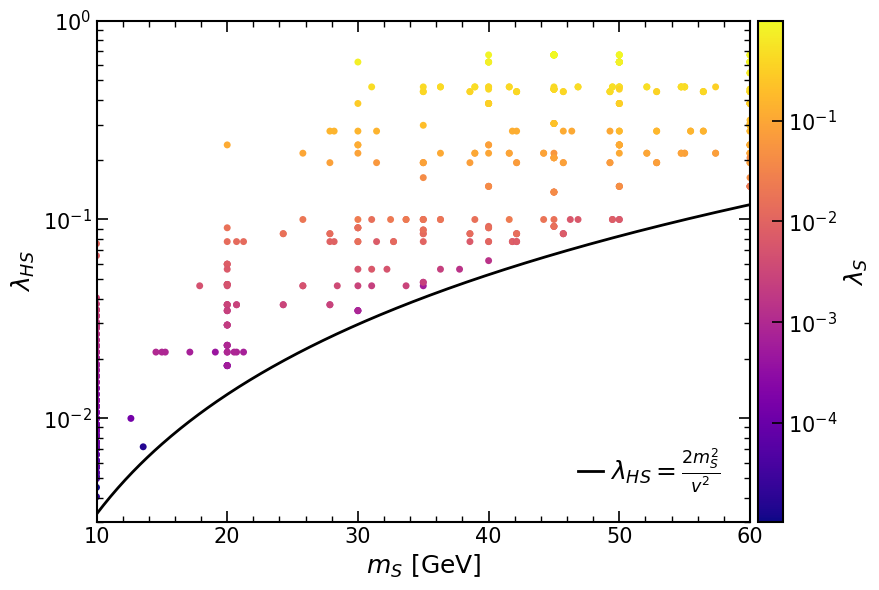

In [19]:
df = Df[(Df.status=='Nucleation_FOPT')&(Df.xic>1)]

# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/246.22**2

cmap = plt.cm.plasma
norm = LogNorm(vmin=df['lS'].min(), vmax=df['lS'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['m2'], df['lHS'], c=df['lS'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_S^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_S \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(10, 60)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\lambda_S$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# Log-scale colorbar ticks
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"$\mathbb{Z}_2$ limit. $\exists T_n$", loc='left', fontsize=20)
plt.tight_layout()
plt.savefig("Figures/Scan_m2-lHS_nucleation.pdf", format="pdf", bbox_inches="tight")
plt.show()


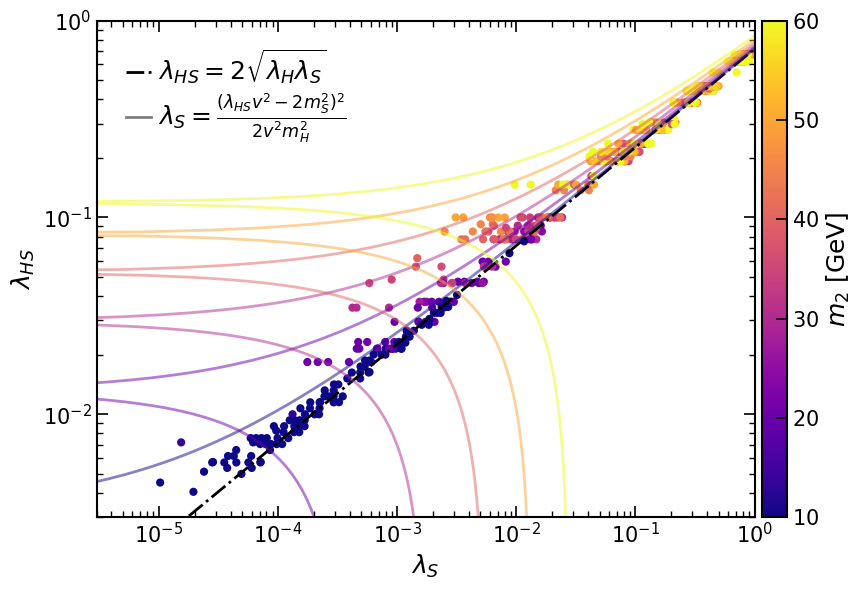

In [20]:
df = Df[(Df.status=='Nucleation_FOPT')&(Df.xic>1)]

cmap = plt.cm.plasma
norm = Normalize(vmin=df['m2'].min(), vmax=df['m2'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))


# SM values (adjust if you're using different fixed values)
m1 = 125.20  # GeV
v0 = 246.22   # GeV
lH = 0.5*m1**2/v0**2

def lS_min(lHS, m2):
    return (lHS * v0**2 - 2 * m2**2)**2 / (2 * v0**2 * m1**2)

lHS_vals = np.geomspace(1e-3, 1e0, 300)
LSCrit   = lHS_vals**2/(4*lH)
ax.plot(LSCrit, lHS_vals, c='k', lw=2, ls='-.')

m2_lines = [10, 20, 30, 40, 50, 60]

for m2_i in m2_lines:
    lS_curve = lS_min(lHS_vals, m2_i)
    ax.plot(lS_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2)

sc = ax.scatter(df['lS'], df['lHS'], c=df['m2'], cmap=cmap, norm=norm,
                 s=35, alpha=1, edgecolors='None')

ax.set_xlabel(r'$\lambda_S$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(3e-6, 1e0)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$m_2\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

handles_list = [mlines.Line2D([], [], color='k', linestyle='-.', linewidth=2, alpha=1, label=r"$\lambda_{HS}=2\sqrt{\lambda_H \lambda_S}$"),
                mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{(\lambda_{HS}v^2 - 2m_S^2)^2}{2v^2m_H^2}$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"$\mathbb{Z}_2$ Limit. $\exists T_n$", loc='left', fontsize=20)
plt.tight_layout()
plt.savefig("Figures/Scan_lS-lHS_Nucleation.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [44]:
Df[(Df.lS>1.5e-1)&(Df.lS<2e-1)&(Df.lHS>2e-1)&(Df.lHS<3e-1)&(Df.status=='Nucleation_FOPT')&(Df.xic>1)]

,m1,m2,th,v0,lHS,lS,mu3,Tc,xic,Tc_Test,xic_Test,Tn,status,error_msg
9,125.2,30.000000,0.0,246.22,0.278256,0.151290,0.0,74.118441,3.177179,74.118441,3.177179,69.157968,Nucleation_FOPT,NaN
17,125.2,50.000000,0.0,246.22,0.278256,0.176454,0.0,110.311476,1.843037,110.311476,1.843037,109.190191,Nucleation_FOPT,NaN
21,125.2,60.000000,0.0,246.22,0.278256,0.187616,0.0,123.702431,1.063373,123.702431,1.063373,123.321016,Nucleation_FOPT,NaN
31,125.2,28.181818,0.0,246.22,0.278256,0.155087,0.0,73.794856,3.193134,73.794856,3.193134,70.710002,Nucleation_FOPT,NaN
48,125.2,55.454545,0.0,246.22,0.278256,0.154027,0.0,112.713425,1.774797,112.713425,1.774797,108.480775,Nucleation_FOPT,NaN
259,125.2,27.857143,0.0,246.22,0.278256,0.155744,0.0,73.739402,3.195884,73.739402,3.195884,70.971507,Nucleation_FOPT,NaN
288,125.2,52.857143,0.0,246.22,0.278256,0.164901,0.0,111.527793,1.808345,111.527793,1.808345,108.770430,Nucleation_FOPT,NaN
535,125.2,60.000000,0.0,246.22,0.297635,0.156432,0.0,112.621981,1.776924,112.621981,1.776924,105.723822,Nucleation_FOPT,NaN


In [39]:
0.5*125.2**2/246.22**2

0.1292801978686813

In [45]:
2*np.sqrt(0.1292801978686813*0.187616)

np.float64(0.31148055222328414)